# **Introduction**

The ability to describe visual content in words is something humans perform effortlessly, yet it
remains a significant challenge for machines. Image captioning requires not only recognising
objects, scenes, and relationships within an image but also expressing that understanding as a
grammatically coherent and contextually appropriate sentence. Since the introduction of encoder-
decoder neural architectures in the mid-2010s, the field has made remarkable progress; however, a
persistent gap exists between research benchmarks and practical, accessible deployment.


## **Project Goals**
The primary objective of this project is to develop a deep learning model capable of generating descriptive captions for images automatically. We aim to harness the complementary strengths of CNNs and LSTMs to extract meaningful image features and generate coherent textual descriptions. By training our model on the Flickr8k dataset, we seek to demonstrate its ability to produce accurate and contextually relevant captions for a diverse range of images.

## **Dataset Description**
We will be using the Flickr8k dataset, a widely used benchmark dataset for image captioning research. The dataset consists of 8,000 images collected from the Flickr website, each paired with five descriptive captions. These captions provide rich and diverse annotations for the images, covering a wide range of semantic concepts and linguistic styles. By leveraging this dataset, we can train our model to understand the visual content of images and generate corresponding textual descriptions effectively.

# **Model Architecture:**
​
Our image captioning model architecture combines the strengths of Convolutional Neural Networks (CNNs) and Long Short-Term Memory networks (LSTMs). Here's how it works:
​
### **Convolutional Neural Network (CNN):**
​
We utilize a pre-trained CNN, such as VGG16 or ResNet, to extract features from input images. In the provided code, we use the VGG16 model pre-trained on the ImageNet dataset.
By removing the fully connected layers of the CNN and keeping the convolutional layers, we obtain a fixed-size feature vector representing each image's visual content.
​
### **Long Short-Term Memory network (LSTM):**
​
The LSTM component processes the image features extracted by the CNN and generates captions word by word.
In the code, we implement an LSTM-based sequence-to-sequence architecture, where the image features serve as input to the LSTM decoder.
The LSTM decoder generates a sequence of words one token at a time, conditioning each word on the previously generated words and the image features.


# **Training Process:**

Our model is trained using the Flickr8k dataset, following these steps:

### **Feature Extraction:**

We use the pre-trained CNN (VGG16) to extract image features. These features are obtained by passing each image through the CNN and extracting the output of a specific layer.
In the provided code, we extract features from the 'block5_conv3' layer of VGG16, resulting in a 7x7x512 feature tensor for each image.

### **Caption Generation:**

The LSTM decoder takes the image features and generates captions word by word.
During training, the LSTM decoder is fed the image features along with the start token "<start>" to initiate the caption generation process.
The decoder generates the next word in the sequence based on the previous word and the image features, using teacher forcing to provide the ground truth word at each step.
    
### **Loss Calculation:**

We calculate the loss between the predicted captions and the ground truth captions using categorical cross-entropy loss.
The loss is computed over all time steps and all training samples and serves as a measure of how well the model is performing.

### **Evaluation and Fine-Tuning:**

We evaluate the model's performance using metrics such as BLEU score, which compares the generated captions with the reference captions.
Hyperparameters like learning rate, batch size, and optimizer settings are fine-tuned to improve the model's performance on the validation set.

In [2]:
import os   # handling the files
import pickle # storing numpy features
import numpy as np
from tqdm.notebook import tqdm # how much data is process till now

from tensorflow.keras.applications.vgg16 import VGG16 , preprocess_input # extract features from image data.
from tensorflow.keras.preprocessing.image import load_img , img_to_array
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.utils import to_categorical, plot_model
from tensorflow.keras.layers import Input , Dense , LSTM , Embedding , Dropout , add

**os** - used to handle files using system commands.

**pickle** - used to store numpy features extracted

**numpy** - used to perform a wide variety of mathematical operations on arrays

**tqdm** - progress bar decorator for iterators. Includes a default range iterator printing to stderr.

**VGG16, preprocess_input** - imported modules for feature extraction from the image data

**load_img, img_to_array** - used for loading the image and converting the image to a numpy array

**Tokenizer** - used for loading the text as convert them into a token

**pad_sequences** - used for equal distribution of words in sentences filling the remaining spaces with zeros

**plot_model** - used to visualize the architecture of the model through different images

In [3]:
BASE_DIR = '/kaggle/input/datasets/adityajn105/flickr8k'
WORKING_DIR = '/kaggle/working'

# Extract Image Features

We have to load and restructure the model

VGG-16 is a convolutional neural network that is 16 layers deep. You can load a pretrained version of the network trained on more than a million images from the ImageNet database [1]. The pretrained network can classify images into 1000 object categories, such as keyboard, mouse, pencil, and many animals.

In [4]:
# Load vgg16 Model
model = VGG16()

# restructure model
model = Model(inputs = model.inputs , outputs = model.layers[-2].output)

# Summerize
print(model.summary())

I0000 00:00:1775997703.355836      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1775997703.361735      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,260,544 (512.16 MB)

 Trainable params: 134,260,544 (512.16 MB)

 Non-trainable params: 0 (0.00 B)

None


# Extract the image features
Now we extract the image features and load the data for preprocess

In [5]:
# extract features from image
features = {}
directory = os.path.join('/kaggle/input/datasets/adityajn105/flickr8k', 'Images')

for img_name in tqdm(os.listdir(directory)):
    # load the image from file
    img_path = directory + '/' + img_name
    image = load_img(img_path, target_size=(224, 224))
    # convert image pixels to numpy array
    image = img_to_array(image)
    # reshape data for model
    image = image.reshape((1, image.shape[0], image.shape[1], image.shape[2]))
    # preprocess image for vgg
    image = preprocess_input(image)
    # extract features
    feature = model.predict(image, verbose=0)
    # get image ID
    image_id = img_name.split('.')[0]
    # store feature
    features[image_id] = feature

  0%|          | 0/8091 [00:00<?, ?it/s]

I0000 00:00:1775997739.856324     128 service.cc:152] XLA service 0x7fba3c0042d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775997739.856365     128 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1775997739.856369     128 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1775997740.107287     128 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1775997743.411855     128 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Dictionary 'features' is created and will be loaded with the extracted features of image data

**load_img(img_path, target_size=(224, 224))** - custom dimension to resize the image when loaded to the array

**image.reshape((1, image.shape[0], image.shape[1], image.shape[2]))** - reshaping the image data to preprocess in a RGB type image.

**model.predict(image, verbose=0)** - extraction of features from the image

**img_name.split('.')[0]** - split of the image name from the extension to load only the image name.

In [6]:
# store features in pickle
pickle.dump(features, open(os.path.join(WORKING_DIR, 'features.pkl'), 'wb'))

Extracted features are not stored in the disk, so re-extraction of features can extend running time

Dumps and store your dictionary in a pickle for reloading it to save time

In [7]:
# load features from pickle
with open(os.path.join(WORKING_DIR, 'features.pkl'), 'rb') as f:
    features = pickle.load(f)

## Load the Captions Data

Let us store the captions data from the text file

In [8]:
with open(os.path.join(BASE_DIR, 'captions.txt'), 'r') as f:
    next(f)
    captions_doc = f.read()

### Now we split and append the captions data with the image

In [9]:
from tqdm import tqdm
# create mapping of image to captions
mapping = {}
# process lines
for line in tqdm(captions_doc.split('\n')):
    # split the line by comma(,)
    tokens = line.split(',')
    if len(line) < 2:
        continue
    image_id, caption = tokens[0], tokens[1:]
    # remove extension from image ID
    image_id = image_id.split('.')[0]
    # convert caption list to string
    caption = " ".join(caption)
    # create list if needed
    if image_id not in mapping:
        mapping[image_id] = []
    # store the caption
    mapping[image_id].append(caption)

100%|██████████| 40456/40456 [00:00<00:00, 727449.04it/s]


+ Dictionary 'mapping' is created with key as image_id and values as the corresponding caption text

+ Same image may have multiple captions, **if image_id not in mapping: mapping[image_id] = []** creates a list for appending captions to the corresponding image

In [10]:
len(mapping)

8091

# Preprocess Text Data

In [11]:
import re

def clean(mapping):
    for key, captions in mapping.items():
        for i in range(len(captions)):
            caption = captions[i]

            # lowercase
            caption = caption.lower()

            # remove special characters
            caption = re.sub(r'[^a-zA-Z]', ' ', caption)

            # remove extra spaces (IMPORTANT FIX HERE)
            caption = re.sub(r'\s+', ' ', caption)

            # add start and end tokens
            caption = 'startseq ' + caption + ' endseq'

            captions[i] = caption

Let us visualize the text **before** and **after** cleaning

In [12]:
# before preprocess of text
mapping['1000268201_693b08cb0e']

['A child in a pink dress is climbing up a set of stairs in an entry way .',
 'A girl going into a wooden building .',
 'A little girl climbing into a wooden playhouse .',
 'A little girl climbing the stairs to her playhouse .',
 'A little girl in a pink dress going into a wooden cabin .']

In [16]:
# preprocess the text
clean(mapping)

In [17]:
# after preprocess of text
mapping['1000268201_693b08cb0e']

['startseq startseq a child in a pink dress is climbing up a set of stairs in an entry way endseq endseq',
 'startseq startseq a girl going into a wooden building endseq endseq',
 'startseq startseq a little girl climbing into a wooden playhouse endseq endseq',
 'startseq startseq a little girl climbing the stairs to her playhouse endseq endseq',
 'startseq startseq a little girl in a pink dress going into a wooden cabin endseq endseq']

#### Next we will store the preprocessed captions into a list

In [18]:
all_captions = []
for key in mapping:
    for caption in mapping[key]:
        all_captions.append(caption)

In [19]:
len(all_captions)

40455

# 10 Captions
Let us see the first ten captions

In [20]:
all_captions[:10]

['startseq startseq a child in a pink dress is climbing up a set of stairs in an entry way endseq endseq',
 'startseq startseq a girl going into a wooden building endseq endseq',
 'startseq startseq a little girl climbing into a wooden playhouse endseq endseq',
 'startseq startseq a little girl climbing the stairs to her playhouse endseq endseq',
 'startseq startseq a little girl in a pink dress going into a wooden cabin endseq endseq',
 'startseq startseq a black dog and a spotted dog are fighting endseq endseq',
 'startseq startseq a black dog and a tri colored dog playing with each other on the road endseq endseq',
 'startseq startseq a black dog and a white dog with brown spots are staring at each other in the street endseq endseq',
 'startseq startseq two dogs of different breeds looking at each other on the road endseq endseq',
 'startseq startseq two dogs on pavement moving toward each other endseq endseq']

# Processing of Text Data
Now we start processing the text data

In [21]:
from tensorflow.keras.preprocessing.text import Tokenizer# tokenize the text
tokenizer = Tokenizer()
tokenizer.fit_on_texts(all_captions)
vocab_size = len(tokenizer.word_index) + 1

In [22]:
import pickle

with open('/kaggle/working/tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

print("Tokenizer saved")

Tokenizer saved


In [23]:
vocab_size

8444

No. of unique words

In [24]:
# get maximum length of the caption available
max_length = max(len(caption.split()) for caption in all_captions)
max_length

40

+ Finding the maximum length of the captions, used for reference for the padding sequence.

# Train Test Split

#### After preprocessing the data now we will train, test and split

In [25]:
image_ids = list(mapping.keys())
split = int(len(image_ids) * 0.90)
train = image_ids[:split]
test = image_ids[split:]

**Now we will define a batch and include the padding sequence**

In [26]:
def data_generator(data_keys, mapping, features, tokenizer, max_length, vocab_size, batch_size):
    X1, X2, y = list(), list(), list()
    n = 0
    
    while True:
        for key in data_keys:
            n += 1
            captions = mapping[key]
            
            for caption in captions:
                seq = tokenizer.texts_to_sequences([caption])[0]
                
                for i in range(1, len(seq)):
                    in_seq, out_seq = seq[:i], seq[i]
                    
                    in_seq = pad_sequences([in_seq], maxlen=max_length)[0]
                    out_seq = to_categorical([out_seq], num_classes=vocab_size)[0]
                    
                    X1.append(features[key][0])
                    X2.append(in_seq)
                    y.append(out_seq)
            
            if n == batch_size:
                yield (np.array(X1), np.array(X2)), np.array(y)  
                X1, X2, y = list(), list(), list()
                n = 0

Padding sequence normalizes the size of all captions to the max size filling them with zeros for better results.

# Model Creation

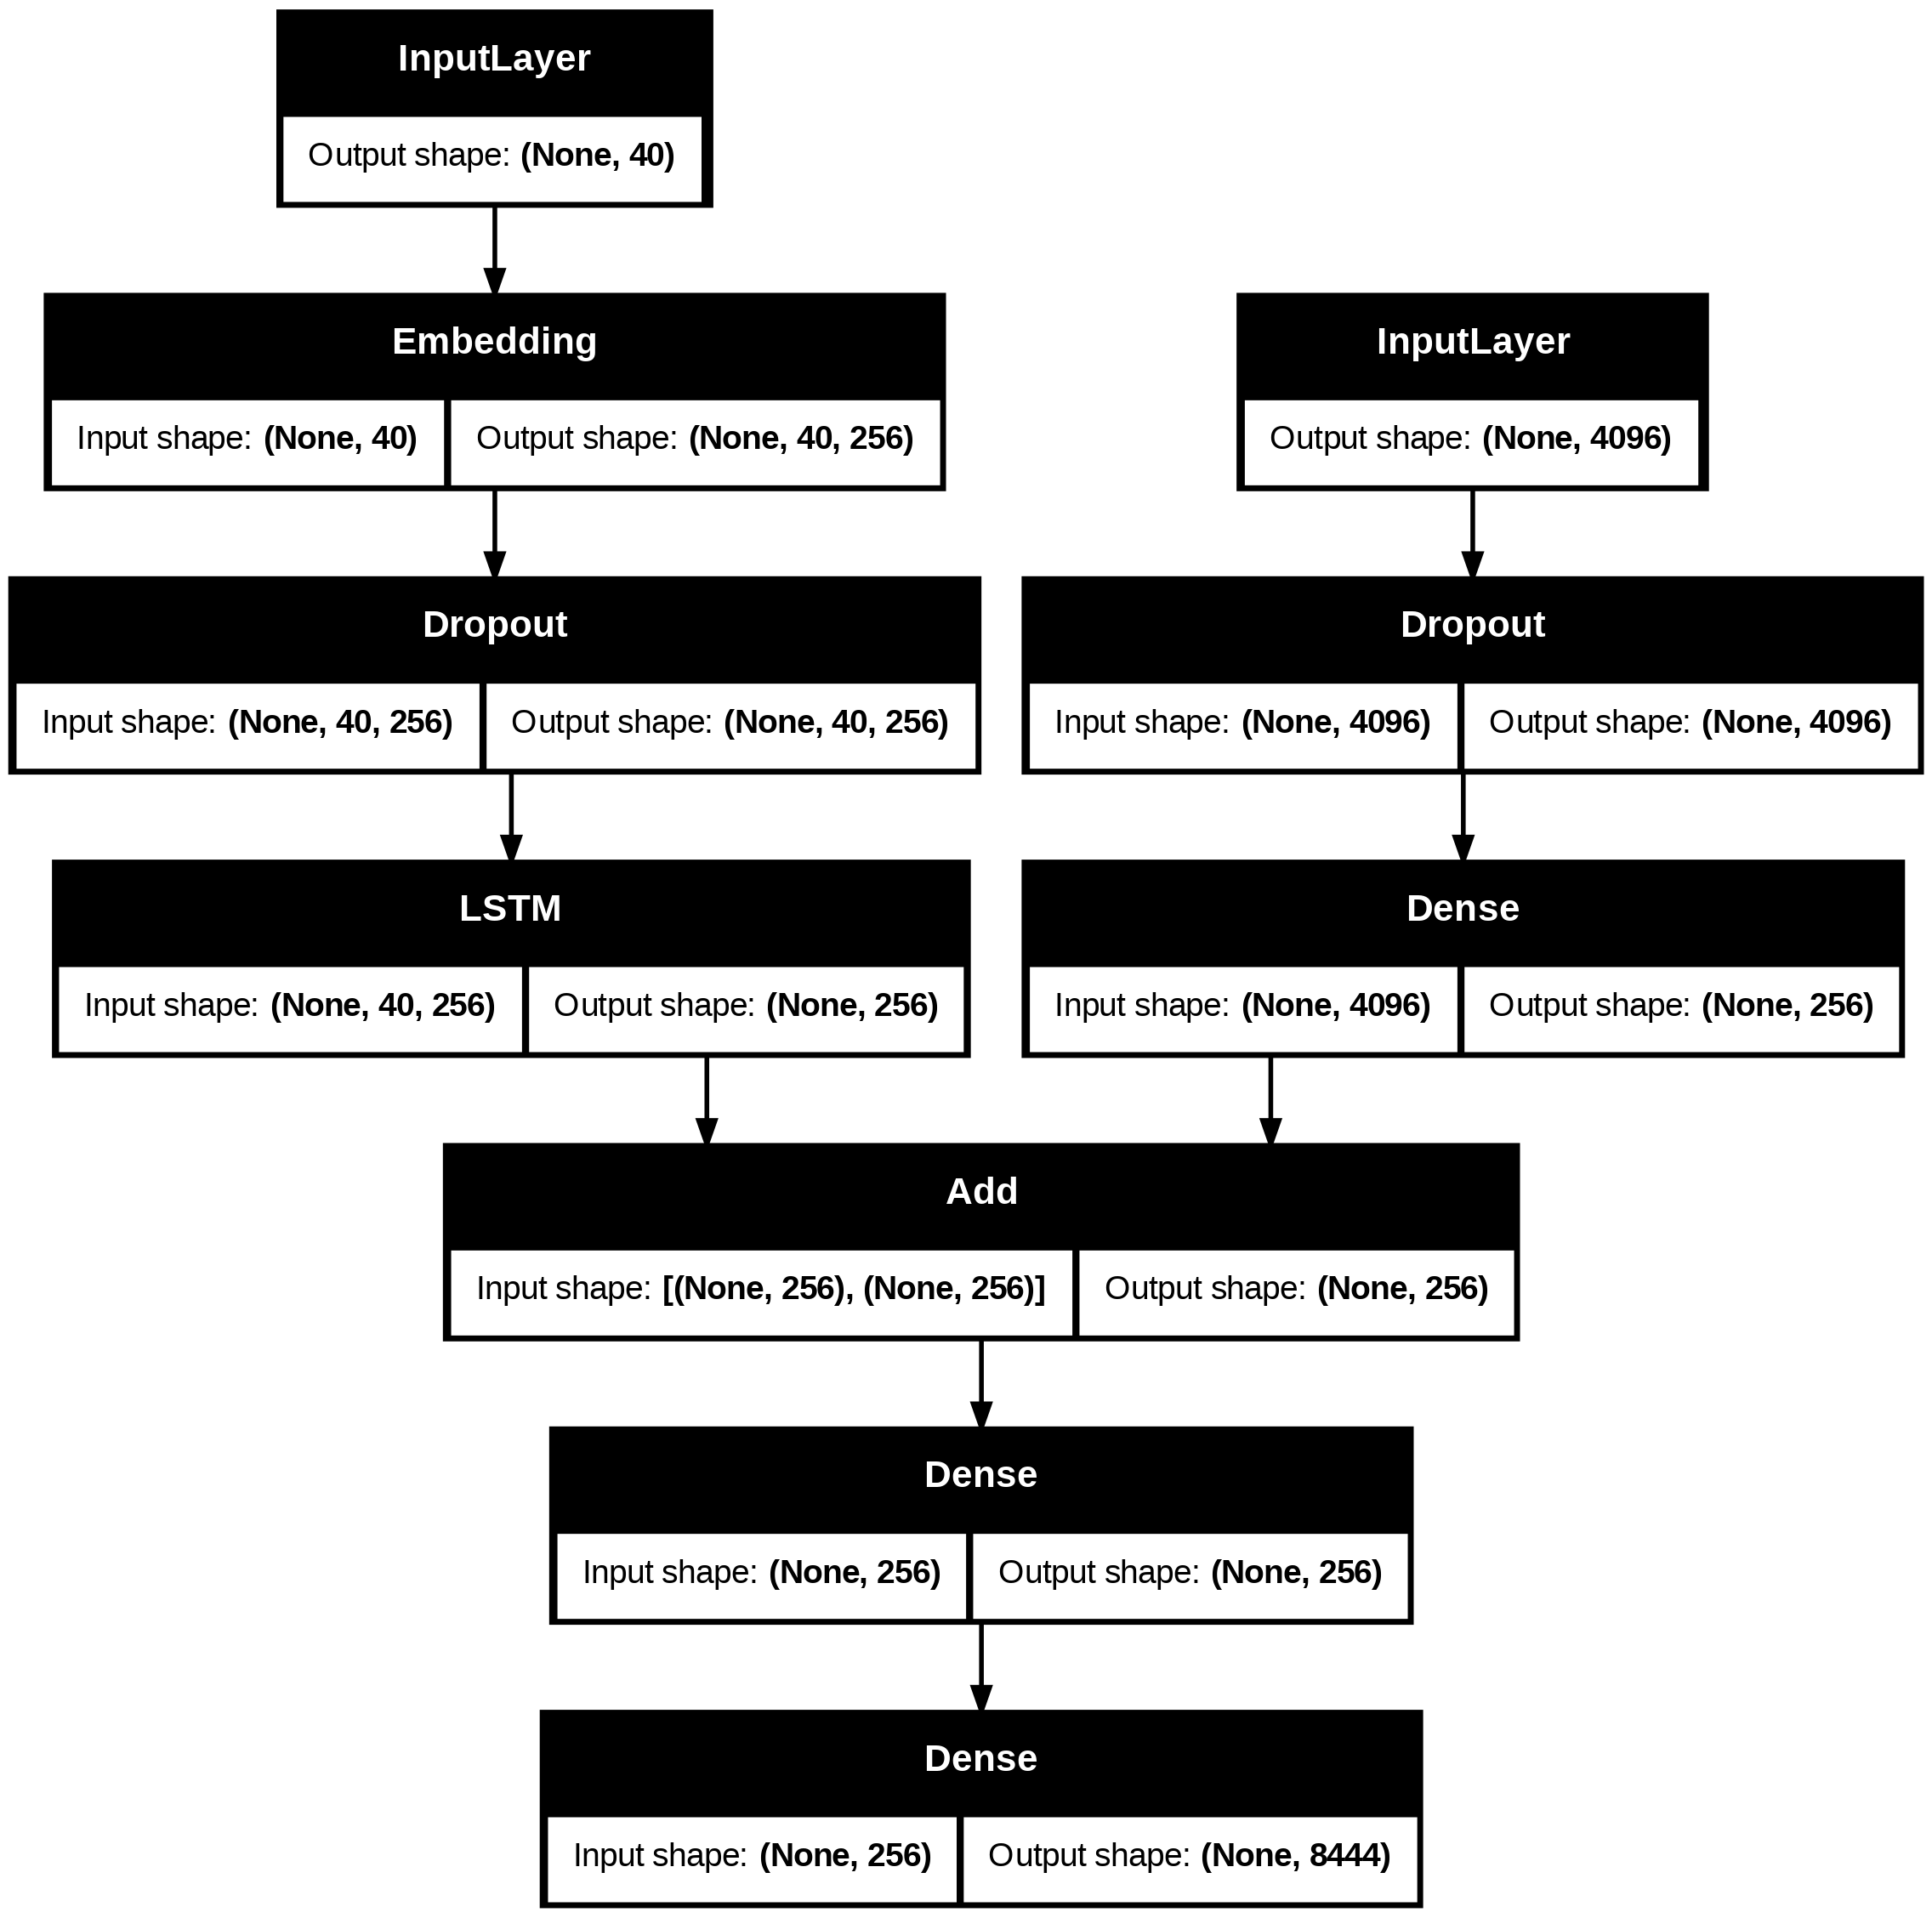

In [27]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, LSTM, Embedding, Dropout, add
from tensorflow.keras.utils import plot_model# encoder model
# image feature layers
inputs1 = Input(shape=(4096,))
fe1 = Dropout(0.4)(inputs1)
fe2 = Dense(256, activation='relu')(fe1)
# sequence feature layers
inputs2 = Input(shape=(max_length,))
se1 = Embedding(vocab_size, 256)(inputs2)
se2 = Dropout(0.4)(se1)
se3 = LSTM(256)(se2)

# decoder model
decoder1 = add([fe2, se3])
decoder2 = Dense(256, activation='relu')(decoder1)
outputs = Dense(vocab_size, activation='softmax')(decoder2)

model = Model(inputs=[inputs1, inputs2], outputs=outputs)
model.compile(loss='categorical_crossentropy', optimizer='adam')

# plot the model
plot_model(model, show_shapes=True)

+ **shape=(4096,)** - output length of the features from the VGG model

+ **Dense** - single dimension linear layer array

+ **Dropout()** - used to add regularization to the data, avoiding over fitting & dropping out a fraction of the data from the layers

+ **model.compile()** - compilation of the model

+ **loss=’sparse_categorical_crossentropy’** - loss function for category outputs

+ **optimizer=’adam’** - automatically adjust the learning rate for the model over the no. of epochs

+ Model plot shows the concatenation of the inputs and outputs into a single layer

+ Feature extraction of image was already done using VGG, no CNN model was needed in this step.

In [28]:
import os
import numpy as np
import pickle
import re
from tqdm import tqdm

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical, plot_model
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, LSTM, Embedding, Dropout, add

# Train Model
Now let us train the model

In [29]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
# train the model
epochs = 20
batch_size = 32
steps = len(train) // batch_size

for i in range(epochs):
    # create data generator
    generator = data_generator(train, mapping, features, tokenizer, max_length, vocab_size, batch_size)
    # fit for one epoch
    model.fit(generator, epochs=1, steps_per_epoch=steps, verbose=1)

227/227 ━━━━━━━━━━━━━━━━━━━━ 74s 309ms/step - loss: 4.8181
227/227 ━━━━━━━━━━━━━━━━━━━━ 69s 305ms/step - loss: 3.0786
227/227 ━━━━━━━━━━━━━━━━━━━━ 69s 305ms/step - loss: 2.7177
227/227 ━━━━━━━━━━━━━━━━━━━━ 69s 304ms/step - loss: 2.5063
227/227 ━━━━━━━━━━━━━━━━━━━━ 69s 304ms/step - loss: 2.3508
227/227 ━━━━━━━━━━━━━━━━━━━━ 69s 305ms/step - loss: 2.2378
227/227 ━━━━━━━━━━━━━━━━━━━━ 69s 305ms/step - loss: 2.1512
227/227 ━━━━━━━━━━━━━━━━━━━━ 69s 304ms/step - loss: 2.0848
227/227 ━━━━━━━━━━━━━━━━━━━━ 69s 304ms/step - loss: 2.0260
227/227 ━━━━━━━━━━━━━━━━━━━━ 70s 306ms/step - loss: 1.9758
227/227 ━━━━━━━━━━━━━━━━━━━━ 69s 304ms/step - loss: 1.9304
227/227 ━━━━━━━━━━━━━━━━━━━━ 70s 308ms/step - loss: 1.8910
227/227 ━━━━━━━━━━━━━━━━━━━━ 70s 306ms/step - loss: 1.8536
227/227 ━━━━━━━━━━━━━━━━━━━━ 69s 305ms/step - loss: 1.8171
227/227 ━━━━━━━━━━━━━━━━━━━━ 69s 304ms/step - loss: 1.7857
227/227 ━━━━━━━━━━━━━━━━━━━━ 69s 303ms/step - loss: 1.7543
227/227 ━━━━━━━━━━━━━━━━━━━━ 69s 304ms/step - loss: 1.72

+ **steps = len(train) // batch_size** - back propagation and fetch the next data

+ Loss decreases gradually over the iterations

+ Increase the no. of epochs for better results

+ Assign the no. of epochs and batch size accordingly for quicker results


### You can save the model in the working directory for reuse

In [30]:
model.save('/kaggle/working/best_model.keras')

In [31]:
import pickle

with open('/kaggle/working/tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

# Generate Captions for the Image

In [32]:
def idx_to_word(integer, tokenizer):
    for word, index in tokenizer.word_index.items():
        if index == integer:
            return word
    return None

+ Convert the predicted index from the model into a word

In [33]:
# generate caption for an image
def predict_caption(model, image, tokenizer, max_length):
    # add start tag for generation process
    in_text = 'startseq'
    # iterate over the max length of sequence
    for i in range(max_length):
        # encode input sequence
        sequence = tokenizer.texts_to_sequences([in_text])[0]
        # pad the sequence
        sequence = pad_sequences([sequence], max_length)
        # predict next word
        yhat = model.predict([image, sequence], verbose=0)
        # get index with high probability
        yhat = np.argmax(yhat)
        # convert index to word
        word = idx_to_word(yhat, tokenizer)
        # stop if word not found
        if word is None:
            break
        # append word as input for generating next word
        in_text += " " + word
        # stop if we reach end tag
        if word == 'endseq':
            break
    return in_text

+ Captiongenerator appending all the words for an image

+ The caption starts with 'startseq' and the model continues to predict the caption until the 'endseq' appeared

# Model Validation
Now we validate the data using BLEU Score

In [34]:
from nltk.translate.bleu_score import corpus_bleu
# validate with test data
actual, predicted = list(), list()

for key in tqdm(test):
    # get actual caption
    captions = mapping[key]
    # predict the caption for image
    y_pred = predict_caption(model, features[key], tokenizer, max_length)
    # split into words
    actual_captions = [caption.split() for caption in captions]
    y_pred = y_pred.split()
    # append to the list
    actual.append(actual_captions)
    predicted.append(y_pred)
# calcuate BLEU score
print("BLEU-1: %f" % corpus_bleu(actual, predicted, weights=(1.0, 0, 0, 0)))
print("BLEU-2: %f" % corpus_bleu(actual, predicted, weights=(0.5, 0.5, 0, 0)))


100%|██████████| 810/810 [15:17<00:00,  1.13s/it]


BLEU-1: 0.617739
BLEU-2: 0.447407


+ BLEU Score is used to evaluate the predicted text against a reference text, in a list of tokens.

+ The reference text contains all the words appended from the captions data (actual_captions)

+ A BLEU Score more than **0.4 is considered a good result**, for a better score increase the no. of epochs accordingly.

## Visualize the Results

In [35]:
from PIL import Image
import matplotlib.pyplot as plt
def generate_caption(image_name):
    # load the image
    # image_name = "1001773457_577c3a7d70.jpg"
    image_id = image_name.split('.')[0]
    img_path = os.path.join(BASE_DIR, "Images", image_name)
    image = Image.open(img_path)
    captions = mapping[image_id]
    print('---------------------Actual---------------------')
    for caption in captions:
        print(caption)
    # predict the caption
    y_pred = predict_caption(model, features[image_id], tokenizer, max_length)
    print('--------------------Predicted--------------------')
    print(y_pred)
    plt.imshow(image)

+ Image caption generator defined

+ First prints the actual captions of the image then prints a predicted caption of the image

---------------------Actual---------------------
startseq startseq a black dog and a spotted dog are fighting endseq endseq
startseq startseq a black dog and a tri colored dog playing with each other on the road endseq endseq
startseq startseq a black dog and a white dog with brown spots are staring at each other in the street endseq endseq
startseq startseq two dogs of different breeds looking at each other on the road endseq endseq
startseq startseq two dogs on pavement moving toward each other endseq endseq
--------------------Predicted--------------------
startseq startseq a black and white dog is playing with a white dog endseq


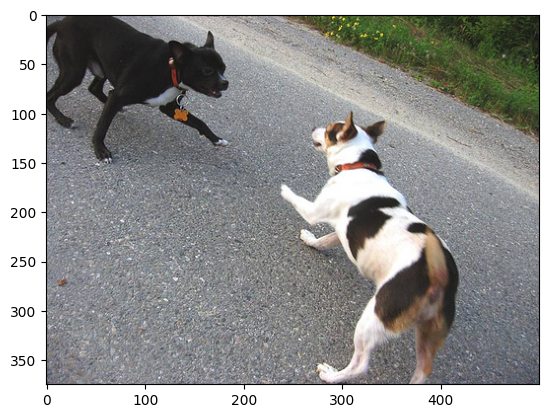

In [37]:
generate_caption("1001773457_577c3a7d70.jpg")

In [39]:
!pip uninstall -y googletrans httpx
!pip install gtts deep-translator

Found existing installation: googletrans 4.0.0rc1
Uninstalling googletrans-4.0.0rc1:
  Successfully uninstalled googletrans-4.0.0rc1
Found existing installation: httpx 0.13.3
Uninstalling httpx-0.13.3:
  Successfully uninstalled httpx-0.13.3
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 kB 1.9 MB/s eta 0:00:00


In [40]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from tensorflow.keras.models import load_model
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.preprocessing.sequence import pad_sequences

from gtts import gTTS
from IPython.display import Audio, display

from deep_translator import GoogleTranslator

### Import Required Libraries

This cell imports all the libraries required for image caption generation, translation, and text-to-speech conversion.

- **pickle** – Loads the saved tokenizer used during model training.
- **numpy** – Performs numerical computations and array operations.
- **matplotlib.pyplot** – Displays images and visualizes the output.
- **PIL (Python Imaging Library)** – Opens and processes image files.
- **TensorFlow/Keras** – Loads the trained caption generation model, VGG16 feature extractor, and provides image preprocessing and sequence padding utilities.
- **gTTS (Google Text-to-Speech)** – Converts the generated image caption into speech.
- **IPython.display** – Plays the generated audio directly in the notebook.
- **deep_translator (GoogleTranslator)** – Translates the generated caption into different languages.

These libraries together enable image preprocessing, feature extraction, caption generation, language translation, and audio output in the image captioning system.

In [62]:
model = load_model('/kaggle/working/best_model.keras')

with open('/kaggle/working/tokenizer.pkl', 'rb') as f:
    tokenizer = pickle.load(f)

max_length = 40

### Load the Trained Model and Tokenizer

This cell loads the trained image caption generation model and the tokenizer required for converting words into numerical sequences.

- **load_model()** loads the saved deep learning model (`best_model.keras`) that was trained to generate captions from image features.
- **pickle.load()** loads the saved tokenizer (`tokenizer.pkl`), which contains the vocabulary mapping between words and integer indices.
- **max_length = 40** specifies the maximum length of the caption sequence used during both training and prediction. All input sequences are padded to this length before being passed to the model.

Loading these resources ensures that the model can correctly interpret image features and generate meaningful captions during inference.

In [63]:
vgg = VGG16()
vgg = Model(inputs=vgg.inputs, outputs=vgg.layers[-2].output)

print("VGG ready")

VGG ready


In [64]:
def extract_features(img_path):
    image = load_img(img_path, target_size=(224, 224))
    image = img_to_array(image)
    image = image.reshape((1, image.shape[0], image.shape[1], image.shape[2]))
    image = preprocess_input(image)
    return vgg.predict(image, verbose=0)

In [65]:
def idx_to_word(integer, tokenizer):
    for word, index in tokenizer.word_index.items():
        if index == integer:
            return word
    return None


def predict_caption(model, image, tokenizer, max_length):
    in_text = 'startseq'

    for i in range(max_length):
        sequence = tokenizer.texts_to_sequences([in_text])[0]
        sequence = pad_sequences([sequence], max_length)

        yhat = model.predict([image, sequence], verbose=0)
        yhat = np.argmax(yhat)

        word = idx_to_word(yhat, tokenizer)
        if word is None:
            break

        in_text += " " + word

        if word == 'endseq':
            break

    return in_text

### Define Caption Generation Functions

This cell defines two helper functions used to generate captions for input images.


- It begins the caption with the special token **`startseq`**.
- The current caption is converted into a sequence of integers and padded to the maximum sequence length.
- The model predicts the next most probable word based on the image features and the current sequence.
- The predicted word is converted from its integer index to text using the `idx_to_word()` function.
- The new word is appended to the caption, and the process repeats until either:
  - the **`endseq`** token is predicted, or
  - the maximum caption length is reached.

Finally, the function returns the complete generated caption for the input image.

In [66]:
def caption_from_file(img_path):
    # show image
    image = Image.open(img_path)
    plt.imshow(image)
    plt.axis('off')
    plt.show()

    # extract features
    feature = extract_features(img_path)

    # predict caption
    y_pred = predict_caption(model, feature, tokenizer, max_length)
    print("\nRaw:", y_pred)

    # clean caption
    final_caption = y_pred.replace('startseq','').replace('endseq','').strip()
    print("English:", final_caption)

    # Hindi translation
    try:
        hindi_caption = GoogleTranslator(source='auto', target='hi').translate(final_caption)
    except:
        hindi_caption = "Translation failed"

    print("Hindi:", hindi_caption)

    # English audio
    try:
        tts_en = gTTS(text=final_caption, lang='en')
        tts_en.save("english.mp3")
        print("English Audio:")
        display(Audio("english.mp3"))
    except Exception as e:
        print("English audio error:", e)

    # Hindi audio
    try:
        tts_hi = gTTS(text=hindi_caption, lang='hi')
        tts_hi.save("hindi.mp3")
        print("Hindi Audio:")
        display(Audio("hindi.mp3"))
    except Exception as e:
        print("Hindi audio error:", e)

### Generate Caption, Translate, and Convert to Speech

This function performs the complete image captioning pipeline for a given image file.

#### Function: `caption_from_file(img_path)`

The function accepts the path of an input image and performs the following steps:

1. **Display the Image**
   - Opens the input image using the Python Imaging Library (PIL).
   - Displays the image using Matplotlib for visualization.

2. **Extract Image Features**
   - Calls the `extract_features()` function to obtain deep image features using the pre-trained VGG16 model.
   - These features serve as input to the caption generation model.

3. **Generate Image Caption**
   - Uses the trained image captioning model to predict a caption for the image.
   - Prints both the raw caption (including `startseq` and `endseq`) and the cleaned English caption.

4. **Translate the Caption**
   - Translates the English caption into Hindi using the `GoogleTranslator` library.
   - If translation fails, an appropriate error message is displayed.

5. **Generate English Speech**
   - Converts the English caption into speech using Google Text-to-Speech (gTTS).
   - Saves the audio as **english.mp3** and plays it within the notebook.

6. **Generate Hindi Speech**
   - Converts the translated Hindi caption into speech.
   - Saves the audio as **hindi.mp3** and plays it within the notebook.

Overall, this function integrates image visualization, feature extraction, caption generation, language translation, and text-to-speech synthesis, providing both textual and audio descriptions of the input image.

In [67]:
from IPython.display import display
from ipywidgets import FileUpload

uploader = FileUpload(accept='image/*', multiple=False)
display(uploader)

FileUpload(value=(), accept='image/*', description='Upload')

In [68]:
uploaded_file = uploader.value[0]

file_name = uploaded_file['name']

with open(file_name, 'wb') as f:
    f.write(uploaded_file['content'])

img_path = file_name
print("Uploaded:", img_path)

Uploaded: photo.png


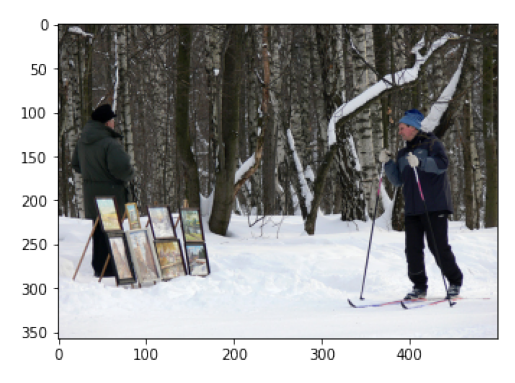


Raw: startseq startseq a man in a black and black coat is standing on a mountain endseq
English: a man in a black and black coat is standing on a mountain
Hindi: काले-काले कोट में एक आदमी पहाड़ पर खड़ा है
English Audio:


Hindi Audio:


In [69]:
caption_from_file("/kaggle/working/photo.png")

In [75]:
from IPython.display import display
from ipywidgets import FileUpload

uploader = FileUpload(accept='image/*', multiple=False)
display(uploader)

FileUpload(value=(), accept='image/*', description='Upload')

In [76]:
uploaded_file = uploader.value[0]

file_name = uploaded_file['name']

with open(file_name, 'wb') as f:
    f.write(uploaded_file['content'])

img_path = file_name
print("Uploaded:", img_path)

Uploaded: output2.jpg


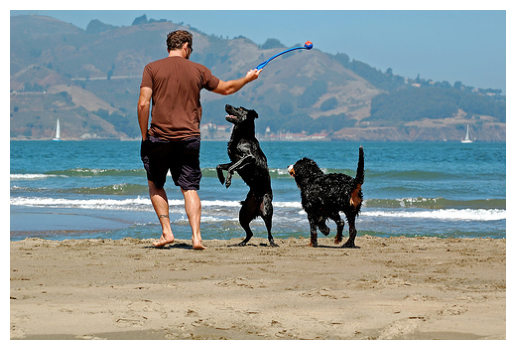


Raw: startseq startseq a man in a black speedo and black pants is running along the beach endseq
English: a man in a black speedo and black pants is running along the beach
Hindi: काली स्पीडो और काली पैंट में एक आदमी समुद्र तट पर दौड़ रहा है
English Audio:


Hindi Audio:


In [77]:
caption_from_file("/kaggle/working/output2.jpg")